# Equispaced Fourier Features for Fast Gaussian Process Regression

In [1]:
import jax
jax.config.update('jax_enable_x64', True)

import jax.numpy as jnp
import jax.random as jr
from jax.scipy.sparse.linalg import cg
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

import nemos as nmo
from nemos.basis import FourierSEBasis

## when do you want to use a GP?

In [2]:
def evaluate_tuning(stimulus):
    return 0.2 * (stimulus ** 3) - 2.5 * (stimulus ** 2) + 6 * stimulus

def generate_observations(key, n_obs, stimulus_min, stimulus_max, noise_sigma):
    stimulus_key, subkey = jr.split(key)
    obs_stimuli = jr.uniform(stimulus_key, shape = (n_obs,), minval = stimulus_min, maxval = stimulus_max)
    true_firing_rate = evaluate_tuning(obs_stimuli)
    firing_rate_key, subkey = jr.split(subkey)
    obs_firing_rate = true_firing_rate + jr.normal(firing_rate_key, shape = (n_obs,)) * noise_sigma
    return obs_stimuli, obs_firing_rate, true_firing_rate

key = jr.key(seed = 0)
n_obs = 100
stimulus_min = 0
stimulus_max = 10
noise_sigma = 1
obs_stimuli, obs_firing_rate, true_firing_rate = generate_observations(key, n_obs, stimulus_min, stimulus_max, noise_sigma)

n_pred = 300
pred_stimuli = jnp.linspace(stimulus_min, stimulus_max, n_pred)

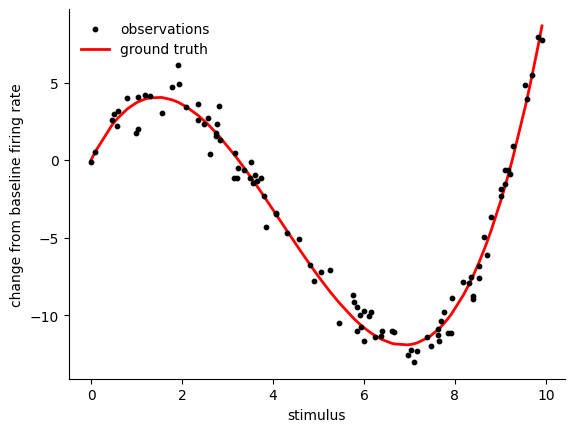

In [3]:
fig, axes = plt.subplots(1, 1)
axes.scatter(obs_stimuli, obs_firing_rate, s = 10, c = 'k', label = 'observations', zorder = 5)
sorted_indices = jnp.argsort(obs_stimuli)
axes.plot(obs_stimuli[sorted_indices], true_firing_rate[sorted_indices], lw = 2, c = 'r', label = 'ground truth')
axes.set_xlabel('stimulus')
axes.set_ylabel('change from baseline firing rate')
axes.legend(frameon = False)

## how does a GP work?

### kernel

In [4]:
length_scale = 0.7
output_scale = 1
def se_kernel(stim_1, stim_2=jnp.array([0]), length_scale=length_scale, output_scale=output_scale):
    diff = stim_1[:, None] - stim_2[None, :]
    return output_scale * jnp.exp(-0.5 * diff**2 / length_scale**2)

# odd count so the symmetric grid contains an exact 0 at index n_test_stimuli // 2;
# the kernel-approximation cell uses that index as the zero-difference reference point.
n_test_stimuli = 101
test_stimuli_diffs = jnp.linspace(-0.5*stimulus_max, 0.5*stimulus_max, n_test_stimuli)
kernel_evals = se_kernel(test_stimuli_diffs)

Text(0, 0.5, 'covariance between stimuli')

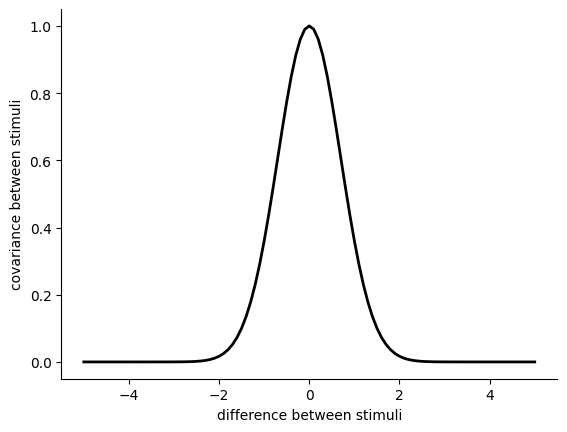

In [5]:
fig, axes = plt.subplots(1, 1)
axes.plot(test_stimuli_diffs, kernel_evals, lw = 2, c = 'k')
axes.set_xlabel('difference between stimuli')
axes.set_ylabel('covariance between stimuli')

### predictive mean

In [6]:
def compute_predictive_mean(pred_stimuli, obs_stimuli, obs_firing_rate, noise_sigma):
    n_obs = obs_stimuli.shape[0]
    K_obs  = se_kernel(obs_stimuli, obs_stimuli) + (noise_sigma**2) * jnp.eye(n_obs)
    K_cross = se_kernel(pred_stimuli, obs_stimuli)
    L = jnp.linalg.cholesky(K_obs)
    w = jnp.linalg.solve(L.T, jnp.linalg.solve(L, obs_firing_rate))
    mu_pred = K_cross @ w
    return mu_pred

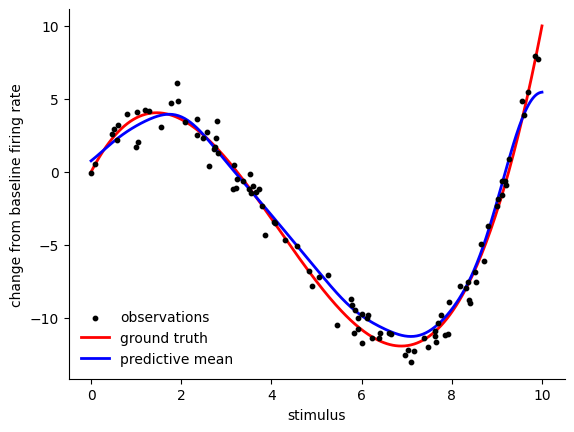

In [7]:
fig, axes = plt.subplots(1, 1)
axes.scatter(obs_stimuli, obs_firing_rate, s = 10, c = 'k', label = 'observations', zorder = 5)
axes.plot(pred_stimuli, evaluate_tuning(pred_stimuli), lw = 2, c = 'r', label = 'ground truth')
mu_pred = compute_predictive_mean(pred_stimuli, obs_stimuli, obs_firing_rate, noise_sigma)
axes.plot(pred_stimuli, mu_pred, color = 'b', lw = 2, label = 'predictive mean')
axes.set_xlabel('stimulus')
axes.set_ylabel('change from baseline firing rate')
axes.legend(frameon = False)

## what's the problem?

In [8]:
import time

dataset_sizes = jnp.logspace(1, 4, num = 9, dtype = int)
times = []
for (i, size) in enumerate(dataset_sizes):
    key = jr.key(seed = i)
    stimuli, firing_rate, true_firing_rate = generate_observations(key, size, stimulus_min, stimulus_max, noise_sigma)
    start_time = time.perf_counter()
    mu_pred = compute_predictive_mean(pred_stimuli, stimuli, firing_rate, noise_sigma).block_until_ready()
    total_time = time.perf_counter() - start_time
    times.append(total_time)
times = jnp.array(times)

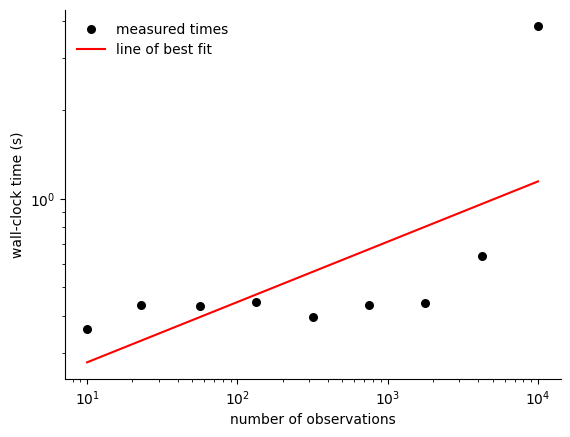

In [9]:
fig, axes = plt.subplots(1, 1, sharex = True)
axes.scatter(dataset_sizes, times, s = 30, c = 'k', label = 'measured times')
p = jnp.polyfit(jnp.log(dataset_sizes), jnp.log(times), 1)
tests = jnp.logspace(1, 4, 50)
fit = jnp.exp(p[-1]) * (tests ** p[0])
axes.plot(tests, fit, c = 'r', label = 'line of best fit')
axes.set_yscale('log')
axes.set_xscale('log')
axes.set_ylabel('wall-clock time (s)')
axes.set_xlabel('number of observations')
axes.legend(frameon = False)

## what do we do?

### Bochner's Theorem

In [10]:
def evaluate_spectral_pdf(frequency, length_scale = length_scale):
    omega_std = 1.0 / length_scale
    return (1 / (jnp.sqrt(2 * jnp.pi) * omega_std)) * jnp.exp(-0.5 * frequency ** 2 / omega_std ** 2)

n_test_frequencies = 100
test_frequencies = jnp.linspace(-4*(1 / length_scale), 4*(1 / length_scale), n_test_frequencies)
spectral_evals = evaluate_spectral_pdf(test_frequencies)

Text(0, 0.5, 'probability density of frequency')

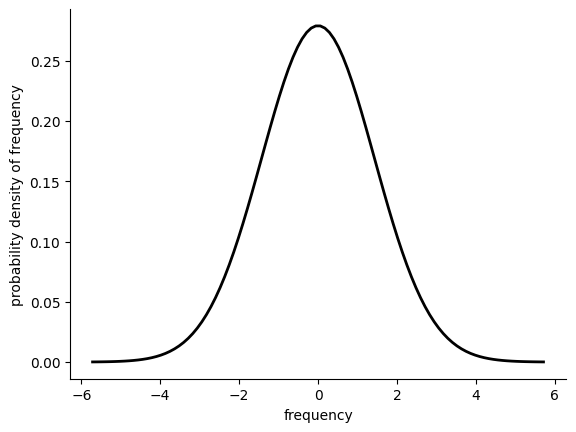

In [11]:
fig, axes = plt.subplots(1, 1)
axes.plot(test_frequencies, spectral_evals, lw = 2, c = 'k')
axes.set_xlabel('frequency')
axes.set_ylabel('probability density of frequency')

## EFGP

### Kernel Approximation

In [12]:
domain = (stimulus_min, stimulus_max)
eps = 1e-4

basis = FourierSEBasis(
    lengthscale=length_scale, domain=domain, eps=eps, variance=output_scale
)

Phi = basis.evaluate(test_stimuli_diffs)
K_pred_approx = Phi @ Phi.T
half_index = test_stimuli_diffs.shape[0] // 2
approx_kernel = K_pred_approx[half_index]

/Users/pgreengard/nemos/src/nemos/basis/_fourier_basis.py:932: UserWarning: FourierSEBasis evaluated at points outside the specified domain [0.0, 10.0].
  warnings.warn(


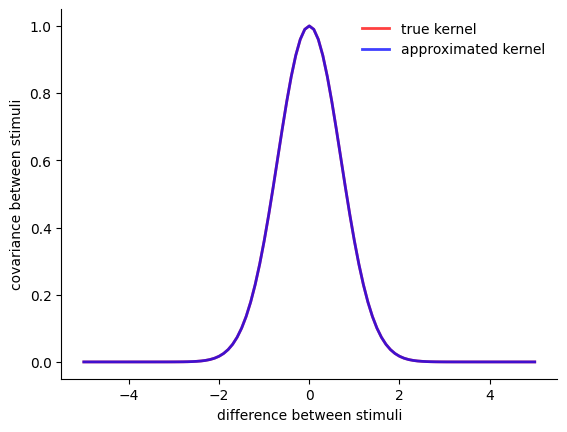

In [13]:
fig, axes = plt.subplots(1, 1)
axes.plot(test_stimuli_diffs, kernel_evals, lw = 2, c = 'r', label = 'true kernel', alpha = 0.75)
axes.plot(test_stimuli_diffs, approx_kernel, lw = 2, c = 'b', label = 'approximated kernel', alpha = 0.75)
axes.set_xlabel('difference between stimuli')
axes.set_ylabel('covariance between stimuli')
axes.legend(frameon = False)

### Regression Approximation

In [14]:
def compute_efgp_mean(pred_stimuli, obs_stimuli, obs_firing_rate, noise_sigma):
    obs_eval = basis.evaluate(obs_stimuli)
    n_weights = obs_eval.shape[1]
    augmented_K_obs = (obs_eval.T @ obs_eval) + (noise_sigma**2) * jnp.eye(n_weights)
    L = jnp.linalg.cholesky(augmented_K_obs)
    beta = jnp.linalg.solve(L.T, jnp.linalg.solve(L, obs_eval.T @ obs_firing_rate))
    w = (obs_firing_rate - obs_eval @ beta) / (noise_sigma ** 2)
    pred_eval = basis.evaluate(pred_stimuli)
    K_cross = pred_eval @ obs_eval.T
    mu_pred = K_cross @ w
    return mu_pred

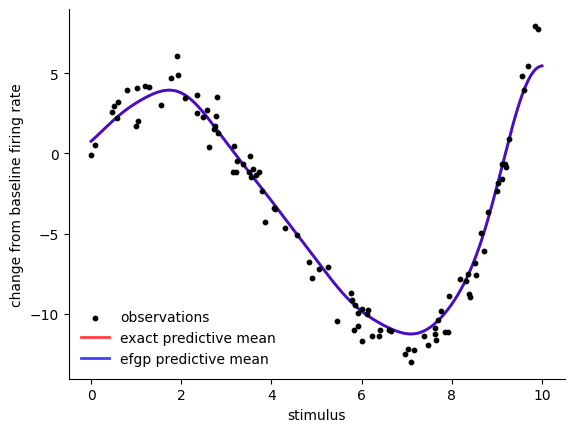

In [15]:
fig, axes = plt.subplots(1, 1)
axes.scatter(obs_stimuli, obs_firing_rate, s = 10, c = 'k', label = 'observations', zorder = 5)
mu_pred = compute_predictive_mean(pred_stimuli, obs_stimuli, obs_firing_rate, noise_sigma)
axes.plot(pred_stimuli, mu_pred, color = 'r', lw = 2, label = 'exact predictive mean', alpha = 0.75)
approx_mu_pred = compute_efgp_mean(pred_stimuli, obs_stimuli, obs_firing_rate, noise_sigma)
axes.plot(pred_stimuli, approx_mu_pred, color = 'b', lw = 2, label = 'efgp predictive mean', alpha = 0.75)
axes.set_xlabel('stimulus')
axes.set_ylabel('change from baseline firing rate')
axes.legend(frameon = False)

### Timing

In [16]:
dataset_sizes = jnp.logspace(1, 4, num = 9, dtype = int)
efgp_times = []
for (i, size) in enumerate(dataset_sizes):
    key = jr.key(seed = i)
    stimuli, firing_rate, true_firing_rate = generate_observations(key, size, stimulus_min, stimulus_max, noise_sigma)
    start_time = time.perf_counter()
    mu_pred = compute_efgp_mean(pred_stimuli, stimuli, firing_rate, noise_sigma).block_until_ready()
    total_time = time.perf_counter() - start_time
    efgp_times.append(total_time)
efgp_times = jnp.array(efgp_times)

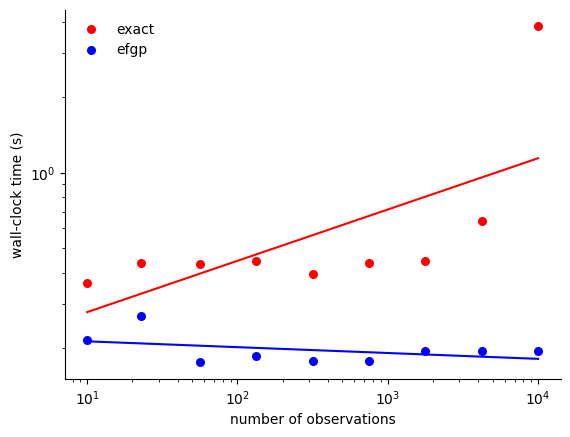

In [17]:
fig, axes = plt.subplots(1, 1, sharex = True)
axes.scatter(dataset_sizes, times, s = 30, c = 'r', label = 'exact')
p = jnp.polyfit(jnp.log(dataset_sizes), jnp.log(times), 1)
tests = jnp.logspace(1, 4, 50)
fit = jnp.exp(p[-1]) * (tests ** p[0])
axes.plot(tests, fit, c = 'r')

axes.scatter(dataset_sizes, efgp_times, s = 30, c = 'b', label = 'efgp')
p = jnp.polyfit(jnp.log(dataset_sizes), jnp.log(efgp_times), 1)
tests = jnp.logspace(1, 4, 50)
fit = jnp.exp(p[-1]) * (tests ** p[0])
axes.plot(tests, fit, c = 'b')

axes.set_yscale('log')
axes.set_xscale('log')
axes.set_ylabel('wall-clock time (s)')
axes.set_xlabel('number of observations')
axes.legend(frameon = False)

### Fast weight-space solve with a Toeplitz apply

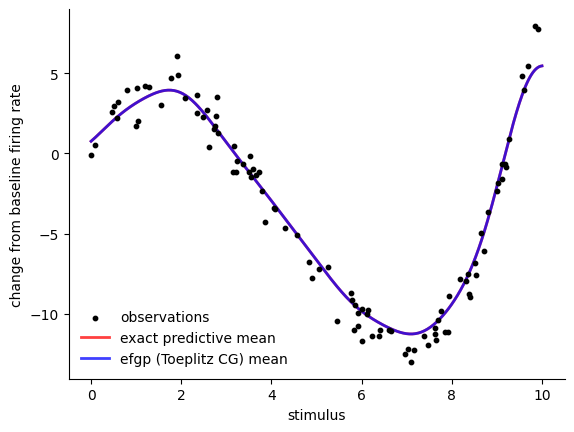

In [18]:
# Due to having an equispaced grid xi_j = j*h in Fourier domain, the weight-space matrix
# Phi^*Phi is Toeplitz so we solve the weight-space system
# (D T D + sigma^2 I) beta = D Phi* y
# with conjugate gradient, applying T in O(m log m) via the FFT -- no matrix is ever formed.
m, h = basis.xis.shape[0] - 1, float(basis.xis[1])
xcen = 0.5 * (basis.domain[0] + basis.domain[1])
w = basis.weights[:m + 1].at[1:].divide(jnp.sqrt(2.0))      # per-mode weights w_0, ..., w_m
ws = jnp.concatenate([w[1:][::-1], w]).astype(complex)      # weights for the modes j = -m, ..., m
js = jnp.arange(-m, m + 1)

def compute_efgp_mean_toeplitz(pred_stimuli, obs_stimuli, obs_firing_rate, noise_sigma):
    phase = 2j * jnp.pi * h * (obs_stimuli[:, None] - xcen)
    V = jnp.exp(phase * jnp.arange(-2 * m, 2 * m + 1)).sum(0)                 # Toeplitz generating vector
    Tv = lambda v: jnp.fft.ifft(jnp.fft.fft(V, 4*m+1) * jnp.conj(jnp.fft.fft(jnp.conj(v), 4*m+1)))[2*m::-1]
    A = lambda c: ws * Tv(ws * c) + noise_sigma**2 * c                        # apply (D T D + sigma^2 I)
    rhs = ws * (jnp.exp(-phase * js).T @ obs_firing_rate.astype(complex))     # D Phi* y
    beta, _ = cg(A, rhs, tol=1e-8)
    F_pred = jnp.exp(2j * jnp.pi * h * (pred_stimuli[:, None] - xcen) * js) * ws
    return jnp.real(F_pred @ beta)

fig, axes = plt.subplots(1, 1)
axes.scatter(obs_stimuli, obs_firing_rate, s = 10, c = 'k', label = 'observations', zorder = 5)
axes.plot(pred_stimuli, compute_predictive_mean(pred_stimuli, obs_stimuli, obs_firing_rate, noise_sigma),
          c = 'r', lw = 2, label = 'exact predictive mean', alpha = 0.75)
axes.plot(pred_stimuli, compute_efgp_mean_toeplitz(pred_stimuli, obs_stimuli, obs_firing_rate, noise_sigma),
          c = 'b', lw = 2, label = 'efgp (Toeplitz CG) mean', alpha = 0.75)
axes.set_xlabel('stimulus')
axes.set_ylabel('change from baseline firing rate')
axes.legend(frameon = False)

## Nonconjugate Weight-Space GPs are just GLMs!